### Environment Setup

In [1]:
# Local environment setup
from pathlib import Path

Librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import gradio as gr

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [3]:
from pathlib import Path

DATASET_DIR = Path("dataset")
if not DATASET_DIR.exists() and (Path("INDIAN_DATASET") / "dataset").exists():
    DATASET_DIR = Path("INDIAN_DATASET") / "dataset"

file_path = DATASET_DIR / "hourlyLoadDataIndia.xlsx" 

In [4]:
df = pd.read_excel(file_path)
df

,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24
2,2019-01-01 02:00:00,114044.14,31730.37,37680.10,12387.36,30760.87,1485.44
3,2019-01-01 03:00:00,113648.97,31529.25,37747.37,12301.12,30616.27,1454.96
4,2019-01-01 04:00:00,116290.05,32406.61,38101.80,12479.13,31839.38,1463.14
...,...,...,...,...,...,...,...
46723,2024-04-30 19:00:00,201094.24,56178.67,63314.47,26449.43,52398.59,2753.07
46724,2024-04-30 20:00:00,196577.71,55006.84,61164.46,26135.97,51599.69,2670.76
46725,2024-04-30 21:00:00,194782.12,52788.73,60500.94,26026.27,52945.71,2520.46
46726,2024-04-30 22:00:00,194967.39,50979.46,61707.05,25467.19,54495.57,2318.11


In [5]:
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (46728, 7)


,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24
2,2019-01-01 02:00:00,114044.14,31730.37,37680.10,12387.36,30760.87,1485.44
3,2019-01-01 03:00:00,113648.97,31529.25,37747.37,12301.12,30616.27,1454.96
4,2019-01-01 04:00:00,116290.05,32406.61,38101.80,12479.13,31839.38,1463.14


Clean the dataset

In [6]:
df['datetime'] = pd.to_datetime(
    df['datetime'],
    errors='coerce'
)

df = df.dropna(subset=['datetime'])

df = df.sort_values('datetime')

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (46728, 7)

Missing values:
datetime                              0
National Hourly Demand                0
Northen Region Hourly Demand          0
Western Region Hourly Demand          0
Eastern Region Hourly Demand          0
Southern Region Hourly Demand         0
North-Eastern Region Hourly Demand    0
dtype: int64


Feature engineering

In [7]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day_of_year'] = df['datetime'].dt.dayofyear

display(
    df[
        [
            'datetime',
            'hour',
            'day',
            'day_of_week',
            'month',
            'year',
            'day_of_year'
        ]
    ].head()
)

,datetime,hour,day,day_of_week,month,year,day_of_year
0,2019-01-01 00:00:00,0,1,1,1,2019,1
1,2019-01-01 01:00:00,1,1,1,1,2019,1
2,2019-01-01 02:00:00,2,1,1,1,2019,1
3,2019-01-01 03:00:00,3,1,1,1,2019,1
4,2019-01-01 04:00:00,4,1,1,1,2019,1


Select features and target

In [8]:
target = 'National Hourly Demand'

features = [
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
    'day_of_year'
]

X = df[features]
y = df[target]

print("Input features:", features)
print("Target:", target)
print("Target unit: MW")

Input features: ['hour', 'day', 'day_of_week', 'month', 'year', 'day_of_year']
Target: National Hourly Demand
Target unit: MW


Train-test split

In [9]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 37382
Testing samples: 9346


Feature scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (37382, 6)
Testing scaled shape: (9346, 6)


SVR model Training

In [11]:
svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

print("SVR model created.")

print("Training SVR...")

svr_model.fit(
    X_train_scaled,
    y_train
)

print("SVR training completed!")

SVR model created.
Training SVR...
SVR training completed!


Make predictions

In [12]:
y_pred = svr_model.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[188794.44251497 188303.42599205 187422.26630354 186178.283478
 184606.98082049 182750.57664727 180656.33822137 178374.80326559
 175957.97588546 173457.5800428 ]


Model evaluation

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("SVR PERFORMANCE")
print("============================")
print(f"MAE  : {mae:.2f} MW")
print(f"MSE  : {mse:.2f} MW²")
print(f"RMSE : {rmse:.2f} MW")
print(f"R²   : {r2:.4f}")

SVR PERFORMANCE
MAE  : 16883.06 MW
MSE  : 418041023.27 MW²
RMSE : 20446.05 MW
R²   : -0.0968


Graph

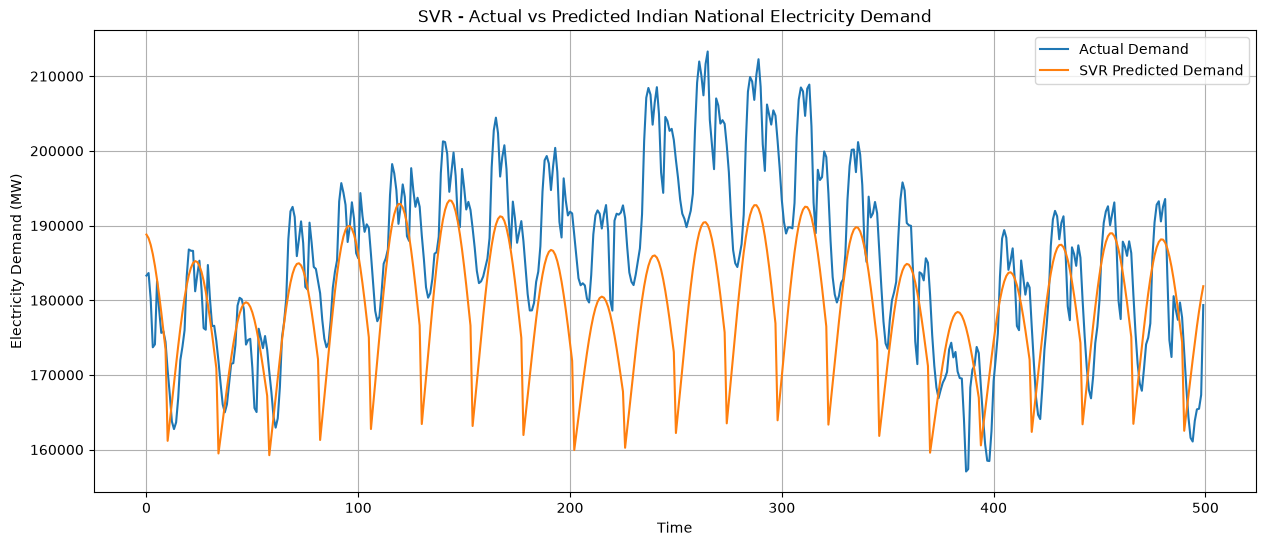

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values[:500],
    label='Actual Demand'
)

plt.plot(
    y_pred[:500],
    label='SVR Predicted Demand'
)

plt.title(
    'SVR - Actual vs Predicted Indian National Electricity Demand'
)

plt.xlabel('Time')
plt.ylabel('Electricity Demand (MW)')

plt.legend()
plt.grid(True)

plt.show()

Save Mode

In [15]:
from pathlib import Path

MODEL_DIR = Path("SVR Model Data")
if not MODEL_DIR.exists() and (Path("INDIAN_DATASET") / "SVR Model Data").exists():
    MODEL_DIR = Path("INDIAN_DATASET") / "SVR Model Data"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "svr_model.pkl"
scaler_path = MODEL_DIR / "svr_scaler.pkl"

joblib.dump(svr_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"SVR Model and Scaler Saved Successfully to {MODEL_DIR}!")

SVR Model and Scaler Saved Successfully to SVR Model Data!


UI

In [16]:
def predict_load_svr(date, time):

    try:

        datetime_value = pd.to_datetime(
            f"{date} {time}"
        )

        input_data = pd.DataFrame({
            'hour': [datetime_value.hour],
            'day': [datetime_value.day],
            'day_of_week': [datetime_value.dayofweek],
            'month': [datetime_value.month],
            'year': [datetime_value.year],
            'day_of_year': [datetime_value.dayofyear]
        })

        input_scaled = scaler.transform(input_data)

        prediction = svr_model.predict(
            input_scaled
        )[0]

        return f"{prediction:,.2f} MW"

    except Exception as e:

        return f"Error: {str(e)}"

In [17]:
result = predict_load_svr(
    "2024-04-01",
    "18:00"
)

print("Predicted National Electricity Demand:")
print(result)

Predicted National Electricity Demand:
170,799.34 MW


In [18]:
# ==============================================================================
# Modern Animated Gradio Interface: Indian Electricity Load Forecasting
# ==============================================================================
import gradio as gr
import pandas as pd

# Preserve original prediction function and add friendly validation error handling
_orig_predict_predict_load_svr = predict_load_svr

def predict_load_svr(date, time):
    if not date or not str(date).strip() or not time or not str(time).strip():
        return "⚠️ Please enter a valid date and time."
    try:
        pd.to_datetime(f"{date} {time}")
    except Exception:
        return "⚠️ Please enter a valid date (YYYY-MM-DD) and time (24-hour format: HH:00)."
    res = _orig_predict_predict_load_svr(date, time)
    if isinstance(res, str):
        if "Not enough previous data" in res:
            return "⚠️ Not enough historical data is available for this prediction."
        if res.startswith("Error:"):
            return "⚠️ Please enter a valid date and time within the dataset range."
    return res

CUSTOM_CSS = """
/* Unified Light-Themed Modern PBL Dashboard Design System */
.gradio-container {
    max-width: 1040px !important;
    margin: 0 auto !important;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial, sans-serif !important;
    background-color: #f8fafc !important;
    color: #1e293b !important;
}

@keyframes fadeInScale {
    0% { opacity: 0; transform: translateY(8px); }
    100% { opacity: 1; transform: translateY(0); }
}

.sg-header-card {
    background: linear-gradient(135deg, #f0fdf4 0%, #eff6ff 50%, #f5f3ff 100%);
    border: 1px solid #e2e8f0;
    border-radius: 20px;
    padding: 28px 30px 24px;
    margin-bottom: 22px;
    text-align: center;
    box-shadow: 0 4px 20px -2px rgba(148, 163, 184, 0.15);
    animation: fadeInScale 0.6s cubic-bezier(0.16, 1, 0.3, 1);
    transition: all 0.3s ease;
}

.sg-header-card:hover {
    transform: translateY(-2px);
    box-shadow: 0 10px 28px -4px rgba(148, 163, 184, 0.22);
}

.sg-badge {
    display: inline-flex;
    align-items: center;
    gap: 6px;
    background: #ffffff;
    color: #2563eb;
    border: 1px solid #bfdbfe;
    font-size: 11px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    padding: 5px 14px;
    border-radius: 9999px;
    margin-bottom: 12px;
    box-shadow: 0 2px 6px rgba(37, 99, 235, 0.08);
}

.sg-title {
    font-size: 26px;
    font-weight: 800;
    color: #0f172a;
    letter-spacing: -0.025em;
    margin: 0 0 4px 0;
}

.sg-title-sub {
    font-size: 16px;
    font-weight: 600;
    color: #059669;
    margin: 0 0 8px 0;
}

.sg-model-tag {
    display: inline-block;
    background: linear-gradient(135deg, #dbeafe 0%, #e0e7ff 100%);
    color: #1e40af;
    font-size: 13px;
    font-weight: 700;
    padding: 4px 14px;
    border-radius: 8px;
    border: 1px solid #bfdbfe;
    margin-bottom: 8px;
}

.sg-subtitle {
    font-size: 13px;
    color: #64748b;
    margin: 0;
}

.sg-card {
    background: #ffffff;
    border: 1px solid #e2e8f0;
    border-radius: 16px;
    padding: 18px 20px;
    margin-bottom: 16px;
    box-shadow: 0 2px 8px -2px rgba(148, 163, 184, 0.1);
    transition: all 0.25s ease;
    animation: fadeInScale 0.7s cubic-bezier(0.16, 1, 0.3, 1);
}

.sg-card:hover {
    transform: translateY(-2px);
    box-shadow: 0 6px 18px -3px rgba(148, 163, 184, 0.16);
}

.sg-card-header {
    font-size: 15px;
    font-weight: 700;
    color: #1e293b;
    margin-bottom: 10px;
    display: flex;
    align-items: center;
    gap: 8px;
}

.sg-btn {
    background: linear-gradient(135deg, #2563eb 0%, #3b82f6 50%, #06b6d4 100%) !important;
    color: #ffffff !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    border: none !important;
    border-radius: 12px !important;
    padding: 12px 24px !important;
    box-shadow: 0 4px 14px rgba(37, 99, 235, 0.28) !important;
    cursor: pointer !important;
    transition: all 0.25s ease !important;
    width: 100% !important;
}

.sg-btn:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 22px rgba(37, 99, 235, 0.38) !important;
    filter: brightness(1.05) !important;
}

.sg-btn:active {
    transform: translateY(0) !important;
}

.sg-info-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
    gap: 14px;
    margin-top: 16px;
}

.sg-meta-row {
    display: flex;
    justify-content: space-between;
    align-items: center;
    font-size: 13px;
    padding: 5px 0;
    border-bottom: 1px dashed #f1f5f9;
}

.sg-meta-row:last-child {
    border-bottom: none;
}

.sg-meta-row span {
    color: #64748b;
}

.sg-meta-row strong {
    color: #0f172a;
    font-weight: 600;
}

.sg-unit-box {
    background: linear-gradient(135deg, #ecfdf5 0%, #d1fae5 100%);
    border: 1px solid #a7f3d0;
    border-radius: 10px;
    padding: 10px 12px;
    margin: 8px 0;
    text-align: center;
}

.sg-unit-val {
    font-size: 17px;
    font-weight: 800;
    color: #065f46;
}

.sg-unit-desc {
    font-size: 11px;
    color: #047857;
    margin-top: 3px;
}

.sg-footer {
    text-align: center;
    padding: 22px 16px 10px;
    margin-top: 24px;
    border-top: 1px solid #e2e8f0;
    color: #64748b;
    font-size: 12px;
    line-height: 1.6;
}

.sg-footer-title {
    font-weight: 700;
    color: #334155;
    font-size: 13px;
    margin-bottom: 4px;
}
"""

with gr.Blocks(title="Indian Electricity Load Forecasting - Support Vector Regression (SVR)") as demo:
    gr.HTML(f"<style>{CUSTOM_CSS}</style>")
    
    # Header Banner Card
    gr.HTML("""
    <div class="sg-header-card">
        <div class="sg-badge">🇮🇳 National Smart Grid Initiative • Kernel Regression</div>
        <div class="sg-title">🇮🇳 Indian Smart Grid</div>
        <div class="sg-title-sub">Electricity Demand &amp; Load Forecasting</div>
        <div class="sg-model-tag">⚡ Support Vector Regression (SVR) Model</div>
        <p class="sg-subtitle">AI-powered prediction of India's national electricity demand</p>
    </div>
    """)
    
    # Input & Output Grid
    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            gr.HTML("""
            <div class="sg-card-header">
                <span>🔮</span>
                <strong>Prediction Input</strong>
            </div>
            """)
            with gr.Row():
                date_input = gr.Textbox(
                    label="📅 Date (YYYY-MM-DD)",
                    placeholder="e.g. 2024-04-01",
                    value="2024-04-01",
                    info="Date format: YYYY-MM-DD"
                )
                time_input = gr.Textbox(
                    label="🕐 Time (24-Hour Format)",
                    placeholder="e.g. 18:00",
                    value="18:00",
                    info="Time format: 24-hour (HH:00)"
                )
            predict_button = gr.Button(
                "⚡ Predict Electricity Demand",
                variant="primary",
                elem_classes=["sg-btn"]
            )
            
        with gr.Column(scale=1):
            gr.HTML("""
            <div class="sg-card-header">
                <span>📊</span>
                <strong>Prediction Result</strong>
            </div>
            """)
            output = gr.Textbox(
                label="🇮🇳 Predicted National Electricity Demand (MW)",
                placeholder="Prediction result with MW unit will appear here...",
                interactive=False,
                lines=3
            )
            
    # Information Cards Grid
    gr.HTML(f"""
    <div class="sg-info-grid">
        <div class="sg-card">
            <div class="sg-card-header">⚡ Electricity Demand Unit</div>
            <div class="sg-unit-box">
                <div class="sg-unit-val">MW — Megawatts</div>
                <div class="sg-unit-desc">Standard unit of national grid electrical power</div>
            </div>
            <p style="font-size: 12px; color: #64748b; margin: 4px 0 0 0; line-height: 1.5;">
                Electricity demand represents the power required by the Indian electricity grid.
            </p>
        </div>
        <div class="sg-card">
            <div class="sg-card-header">🤖 Model Information</div>
            <div class="sg-meta-row"><span>Model:</span> <strong>Support Vector Regression (SVR)</strong></div>
            <div class="sg-meta-row"><span>Dataset:</span> <strong>Indian Hourly Electricity Demand Dataset</strong></div>
            <div class="sg-meta-row"><span>Target:</span> <strong>National Hourly Demand</strong></div>
            <div class="sg-meta-row"><span>Unit:</span> <strong>MW (Megawatts)</strong></div>
            <div class="sg-meta-row"><span>Forecast Type:</span> <strong>Hourly Electricity Demand</strong></div>
            <div class="sg-meta-row"><span>Kernel:</span> <strong>Radial Basis Function (RBF)</strong></div>
        </div>
        <div class="sg-card">
            <div class="sg-card-header">🇮🇳 Dataset</div>
            <div class="sg-meta-row"><span>Source:</span> <strong>Indian Hourly Electricity Demand</strong></div>
            <div class="sg-meta-row"><span>Target:</span> <strong>National Hourly Demand</strong></div>
            <div class="sg-meta-row"><span>Frequency:</span> <strong>Hourly (24 Observations / Day)</strong></div>
            <div class="sg-meta-row"><span>Region:</span> <strong>India (National Grid)</strong></div>
        </div>
    </div>
    <div class="sg-footer">
        <div class="sg-footer-title">🇮🇳 Indian Smart Grid Load Forecasting</div>
        <div>Machine Learning &amp; Deep Learning Project • Linear Regression | SVR | Random Forest | LSTM | XGBoost</div>
        <div style="margin-top: 4px; color: #94a3b8;">Developed for Academic PBL Project</div>
    </div>
    """)

    # Connect Prediction Function
    predict_button.click(
        fn=predict_load_svr,
        inputs=[date_input, time_input],
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
